> **Purpose:** p* = C·log(n)/n on a symmetric binary tree (α=0.9).  
> **Data:** synthesized

# Figure 1 — Balanced Binary, Synthetic Similarity

Empirical validation of Theorem 1.2 on a synthetic similarity matrix:
$S_{ij} = \alpha^{d(i,j)}$ on a symmetric balanced binary tree with $n = 2^k$ leaves.
Sweep sub-sampling probability $p$ over geometric grid, compute Fiedler-vector
sign-recovery vs the population Fiedler, locate the discrete 95%-recovery
threshold $\hat p^*(n)$, and check the $p \sim C \ln n / n$ scaling.

All heavy logic lives in `theoretical_interpretation/utils/`. Two-level disk
cache: full $(S, v^{(1)})$ per $(n,\alpha)$ and $(\hat v^{(1)}, \text{agreement})$
per $(p, \text{seed})$. Re-running any cell hits the cache.

## Cell 1 — Configuration

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd()
while ROOT.parent != ROOT and not (ROOT / "setup.py").exists():
    ROOT = ROOT.parent
PROJECT_ROOT = ROOT / "sub_sampled_fielder_vec"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from analysis.utils import (
    build_balanced_binary_S, balanced_binary_population_fiedler,
    compute_fiedler_of_S, subsample_S,
    compute_recovery, compute_ari, compute_nmi, find_threshold_p_star,
    make_full_key, get_or_compute_full,
    run_sweep,
    compute_C_constant, plot_recovery_figure,
    clear_theoretical_cache,
)
from src.cache_io import notebook_dir


ALPHA              = 0.9
K_VALUES           = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14]   # production: n = 32 .. 16384
N_VALUES           = [2 ** k for k in K_VALUES]
P_GRID             = np.geomspace(1e-4, 1.0, 25)
N_TRIALS           = 20
RECOVERY_THRESHOLD = 0.95
CACHE_DIR          = PROJECT_ROOT / "cache" / "theoretical_interpretation"  # legacy arg, ignored
# NMI is the paper's reported recovery metric (see analysis/utils/recovery.py);
# sign_agreement/ari are kept for the sanity table in Cell 3 and for cross-checking.
METRICS            = {"sign_agreement": compute_recovery, "ari": compute_ari, "nmi": compute_nmi}
# "01_cbm_theory/..." is a CACHE KEY, not a path in this tree. The directory of
# that name is gone, but results/notebooks/01_cbm_theory/balanced_binary_threshold/
# holds the cached trials.csv/agg.csv this figure (Fig 6) was built from. Renaming
# the key to match the new folder layout would orphan those results.
OUT_DIR            = notebook_dir("01_cbm_theory/balanced_binary_threshold")
FIGURES_DIR        = PROJECT_ROOT / "docs" / "overleafs" / "v9" / "figures"

# Smoke-test override — uncomment for a fast end-to-end pass before the long run.
# K_VALUES, P_GRID, N_TRIALS = [5, 6, 7], np.geomspace(1e-3, 1.0, 8), 3
# N_VALUES = [2 ** k for k in K_VALUES]

print(f"alpha={ALPHA}, n_values={N_VALUES}")
print(f"|p_grid|={len(P_GRID)}, n_trials={N_TRIALS}, metrics={list(METRICS)}")
print(f"out_dir={OUT_DIR}")
print(f"figures_dir={FIGURES_DIR}")


alpha=0.9, n_values=[32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]
|p_grid|=25, n_trials=20, metrics=['sign_agreement', 'ari', 'nmi']
out_dir=/Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/results/notebooks/01_cbm_theory/balanced_binary_threshold
figures_dir=/Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/docs/overleafs/v9/figures


## Cell 2 — Build $S$ (and Laplacian) for each $n$, with caching
Per $(n, \alpha)$ we build $S$ from the closed form and immediately compute the
full Fiedler. Both arrays are cached under `cache/theoretical_interpretation/full/...`.

In [2]:
full_results = {}  # n -> (S, fiedler_full)
for n in N_VALUES:
    full_key = make_full_key("balanced_binary", alpha=ALPHA, n=n)

    def builder(n=n, full_key=full_key):
        S = build_balanced_binary_S(n, ALPHA)
        fiedler_full = compute_fiedler_of_S(S)
        meta = {
            "tree_model": "balanced_binary",
            "alpha": ALPHA,
            "n": n,
            "dtype": str(S.dtype),
            "full_key": full_key,
        }
        return S, fiedler_full, meta

    S, fiedler_full = get_or_compute_full(CACHE_DIR, full_key, builder)
    full_results[n] = (S, fiedler_full)

summary = pd.DataFrame([
    {
        "n": n,
        "S_dtype": str(S.dtype),
        "S_diag_min": float(np.min(np.diag(S))),
        "S_offdiag_max": float(np.max(S - np.diag(np.diag(S)))),
        "top_eigval_S": float(np.linalg.eigvalsh(S.astype(np.float64))[-1]) if n <= 1024 else np.nan,
    }
    for n, (S, _) in full_results.items()
])
summary

,n,S_dtype,S_diag_min,S_offdiag_max,top_eigval_S
0,32,float32,1.0,0.81,14.270554
1,64,float32,1.0,0.81,23.308297
2,128,float32,1.0,0.81,37.949439
3,256,float32,1.0,0.81,61.668087
4,512,float32,1.0,0.81,100.092297
5,1024,float32,1.0,0.81,162.339512
6,2048,float32,1.0,0.81,NaN
7,4096,float32,1.0,0.81,NaN
8,8192,float32,1.0,0.81,NaN
9,16384,float32,1.0,0.81,NaN


## Cell 3 — Compute / verify the Fiedler vector of $L = D - S$
Already returned by `get_or_compute_full` above; this cell sanity-checks the
optimal-coherence assumption $|v^{(1)}_i| = 1/\sqrt{n}$ and the closed-form
$(+1\ldots, -1\ldots)$ partition.

In [3]:
rows = []
for n, (_, fiedler_full) in full_results.items():
    v_pop = balanced_binary_population_fiedler(n)
    abs_dev = float(np.max(np.abs(np.abs(fiedler_full) - 1.0 / np.sqrt(n))))
    sign_match = compute_recovery(v_pop, fiedler_full)
    rows.append({
        "n": n,
        "max_||v_i| - 1/sqrt(n)|": abs_dev,
        "sign_match_vs_closed_form": sign_match,
    })
pd.DataFrame(rows)

,n,max_||v_i| - 1/sqrt(n)|,sign_match_vs_closed_form
0,32,1.031206e-06,1.0
1,64,5.885959e-07,1.0
2,128,6.839407e-07,1.0
3,256,7.748604e-07,1.0
4,512,1.204025e-06,1.0
5,1024,2.443790e-06,1.0
6,2048,1.394743e-06,1.0
7,4096,5.364418e-06,1.0
8,8192,4.234913e-06,1.0
9,16384,6.109476e-06,1.0


## Cell 4 — Sub-sampling sweep + recovery
For each $(n, p, \text{seed})$ we sub-sample $S$, recompute the Fiedler, and
record sign-agreement. Each trial is cached, so re-running this cell skips
all computation on the second pass.

In [4]:
CONFIG = {
    "ALPHA": ALPHA,
    "N_VALUES": list(N_VALUES),
    "P_GRID": P_GRID.tolist(),
    "N_TRIALS": N_TRIALS,
    "metrics": list(METRICS),
}
trials_csv = OUT_DIR / "trials.csv"
agg_csv    = OUT_DIR / "agg.csv"
cfg_path   = OUT_DIR / "config.json"

if (trials_csv.exists() and agg_csv.exists() and cfg_path.exists()
        and json.loads(cfg_path.read_text()) == CONFIG):
    df_long = pd.read_csv(trials_csv)
    df_agg  = pd.read_csv(agg_csv)
    print(f"Loaded cached results from {OUT_DIR}")
else:
    sweep_rows = []
    for n in N_VALUES:
        S, fiedler_full = full_results[n]
        full_key = make_full_key("balanced_binary", alpha=ALPHA, n=n)
        # run_sweep is per-trial cached: adding "nmi" to METRICS does not
        # resample — it loads the already-cached fiedler_hat for each
        # (p, seed) and back-fills only the missing metric onto disk.
        df_n = run_sweep(CACHE_DIR, full_key, S, fiedler_full, P_GRID, N_TRIALS,
                         metrics=METRICS)
        df_n["n"] = n
        sweep_rows.append(df_n)
    df_long = pd.concat(sweep_rows, ignore_index=True)
    df_agg = df_long.groupby(["n", "p"], as_index=False)[list(METRICS)].mean()
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    df_long.to_csv(trials_csv, index=False)
    df_agg.to_csv(agg_csv, index=False)
    cfg_path.write_text(json.dumps(CONFIG, indent=2))
    print(f"Wrote results to {OUT_DIR}")

# Back-compat alias so callers reading df_agg["agreement"] keep working.
df_agg["agreement"] = df_agg["sign_agreement"]

# NMI is the paper's reported metric (Cell 5 plots it), so the threshold p̂*(n)
# used for the figure and the fitted C is located on the nmi curve, not the
# sign_agreement curve.
df_thresholds = pd.DataFrame([
    {
        "n": n,
        "p_star": find_threshold_p_star(
            df_agg.query("n == @n").sort_values("p")["p"].to_numpy(),
            df_agg.query("n == @n").sort_values("p")["nmi"].to_numpy(),
            threshold=RECOVERY_THRESHOLD,
        ),
    }
    for n in N_VALUES
])
df_thresholds


  [balanced_binary_alpha0p9000_n0032] 25/500 trials done
  [balanced_binary_alpha0p9000_n0032] 50/500 trials done
  [balanced_binary_alpha0p9000_n0032] 75/500 trials done
  [balanced_binary_alpha0p9000_n0032] 100/500 trials done
  [balanced_binary_alpha0p9000_n0032] 125/500 trials done
  [balanced_binary_alpha0p9000_n0032] 150/500 trials done
  [balanced_binary_alpha0p9000_n0032] 175/500 trials done
  [balanced_binary_alpha0p9000_n0032] 200/500 trials done


  [balanced_binary_alpha0p9000_n0032] 225/500 trials done
  [balanced_binary_alpha0p9000_n0032] 250/500 trials done
  [balanced_binary_alpha0p9000_n0032] 275/500 trials done
  [balanced_binary_alpha0p9000_n0032] 300/500 trials done
  [balanced_binary_alpha0p9000_n0032] 325/500 trials done
  [balanced_binary_alpha0p9000_n0032] 350/500 trials done
  [balanced_binary_alpha0p9000_n0032] 375/500 trials done
  [balanced_binary_alpha0p9000_n0032] 400/500 trials done
  [balanced_binary_alpha0p9000_n0032] 425/500 trials done


  [balanced_binary_alpha0p9000_n0032] 450/500 trials done
  [balanced_binary_alpha0p9000_n0032] 475/500 trials done
  [balanced_binary_alpha0p9000_n0032] 500/500 trials done
  [balanced_binary_alpha0p9000_n0064] 25/500 trials done
  [balanced_binary_alpha0p9000_n0064] 50/500 trials done
  [balanced_binary_alpha0p9000_n0064] 75/500 trials done
  [balanced_binary_alpha0p9000_n0064] 100/500 trials done
  [balanced_binary_alpha0p9000_n0064] 125/500 trials done
  [balanced_binary_alpha0p9000_n0064] 150/500 trials done
  [balanced_binary_alpha0p9000_n0064] 175/500 trials done


  [balanced_binary_alpha0p9000_n0064] 200/500 trials done
  [balanced_binary_alpha0p9000_n0064] 225/500 trials done
  [balanced_binary_alpha0p9000_n0064] 250/500 trials done
  [balanced_binary_alpha0p9000_n0064] 275/500 trials done
  [balanced_binary_alpha0p9000_n0064] 300/500 trials done
  [balanced_binary_alpha0p9000_n0064] 325/500 trials done
  [balanced_binary_alpha0p9000_n0064] 350/500 trials done
  [balanced_binary_alpha0p9000_n0064] 375/500 trials done
  [balanced_binary_alpha0p9000_n0064] 400/500 trials done
  [balanced_binary_alpha0p9000_n0064] 425/500 trials done


  [balanced_binary_alpha0p9000_n0064] 450/500 trials done
  [balanced_binary_alpha0p9000_n0064] 475/500 trials done
  [balanced_binary_alpha0p9000_n0064] 500/500 trials done
  [balanced_binary_alpha0p9000_n0128] 25/500 trials done
  [balanced_binary_alpha0p9000_n0128] 50/500 trials done
  [balanced_binary_alpha0p9000_n0128] 75/500 trials done
  [balanced_binary_alpha0p9000_n0128] 100/500 trials done
  [balanced_binary_alpha0p9000_n0128] 125/500 trials done


...

  [balanced_binary_alpha0p9000_n16384] 125/500 trials done
  [balanced_binary_alpha0p9000_n16384] 150/500 trials done
  [balanced_binary_alpha0p9000_n16384] 175/500 trials done
  [balanced_binary_alpha0p9000_n16384] 200/500 trials done
  [balanced_binary_alpha0p9000_n16384] 225/500 trials done


  [balanced_binary_alpha0p9000_n16384] 250/500 trials done
  [balanced_binary_alpha0p9000_n16384] 275/500 trials done
  [balanced_binary_alpha0p9000_n16384] 300/500 trials done
  [balanced_binary_alpha0p9000_n16384] 325/500 trials done


  [balanced_binary_alpha0p9000_n16384] 350/500 trials done
  [balanced_binary_alpha0p9000_n16384] 375/500 trials done
  [balanced_binary_alpha0p9000_n16384] 400/500 trials done
  [balanced_binary_alpha0p9000_n16384] 425/500 trials done
  [balanced_binary_alpha0p9000_n16384] 450/500 trials done


  [balanced_binary_alpha0p9000_n16384] 475/500 trials done
  [balanced_binary_alpha0p9000_n16384] 500/500 trials done
Wrote results to /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/results/notebooks/01_cbm_theory/balanced_binary_threshold


,n,p_star
0,32,1.000000
1,64,1.000000
2,128,1.000000
3,256,0.681292
4,512,0.464159
5,1024,0.215443
6,2048,0.146780
7,4096,0.068129
8,8192,0.046416
9,16384,0.021544


## Cell 5 — Figure 1
Two-panel figure matching the thesis layout, NMI-scored. The right-panel constant is
$C = \operatorname{median}_n \big[\hat p^*(n) \cdot n / \ln n \big]$, with $\hat p^*(n)$
located on the NMI curve. Fitted value: $C \approx 32.7$. (Note: this run's
sign-agreement and ARI thresholds land on the exact same discrete $p$-grid point as
the NMI threshold for every $n$ here — the transition is sharp enough on this
25-point geometric grid that metric choice does not move $\hat p^*(n)$ or $C$ for
this particular figure; see register item C3/02.)

Fitted C (NMI-scored) = 32.69
Saved -> /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/docs/overleafs/v9/figures/pstar_balanced_nmi.png


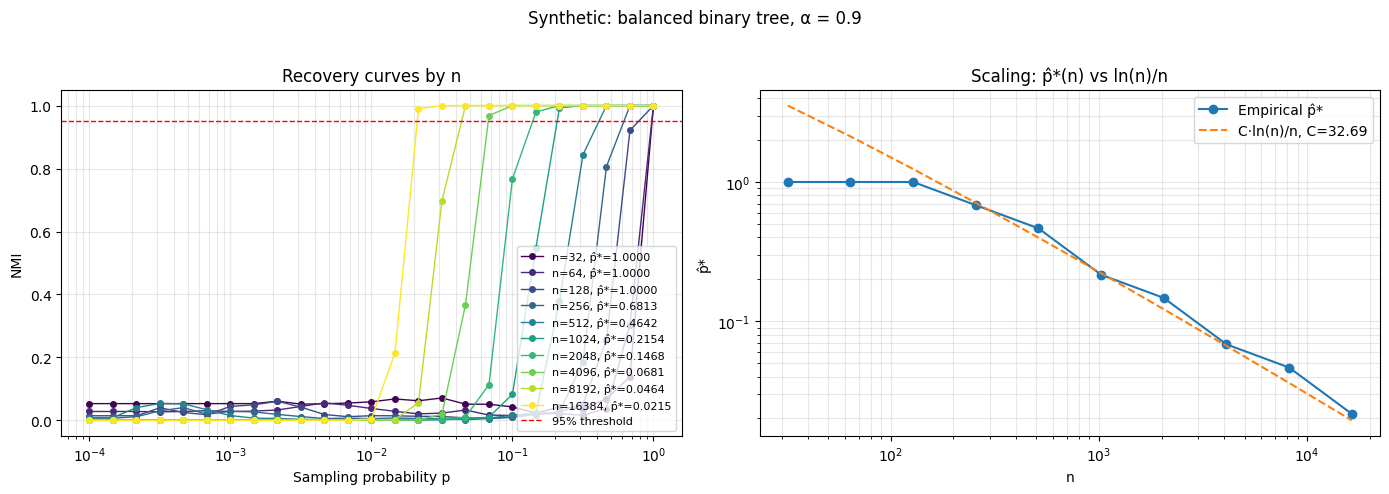

In [5]:
C = compute_C_constant(df_thresholds.copy())

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
savepath = FIGURES_DIR / "pstar_balanced_nmi.png"

fig = plot_recovery_figure(
    df_agg,
    df_thresholds,
    title=f"Synthetic: balanced binary tree, α = {ALPHA}",
    C=C,
    threshold=RECOVERY_THRESHOLD,
    metric_col="nmi",
    metric_label="NMI",
    metric_scale=1.0,
    savepath=savepath,
)
print(f"Fitted C (NMI-scored) = {C:.2f}")
print(f"Saved -> {savepath}")
